# MAJ-Debate: Step 1 EDA and Experimental Preparation
**Authors:** Prajwal Bhandary, Saugat Shakya, Prabidhi Pyakurel, Rahul Shakya  
**Asian Institute of Technology (AIT), NLP Course (Master's Program)**

---
### Notebook Objective
This notebook documents the first experimental step of the MAJ-Debate project: reproducible exploratory data analysis (EDA) and pre-modeling preparation.

### Scope of Work
1. **Dataset EDA**: quantify scale, topic structure, label balance, and preprocessing impact
2. **Diagnostics**: inspect truncation effects, domain coverage, and filtering behavior
3. **Planning Metrics**: estimate complexity and expected ablation trajectories from EDA evidence
4. **Artifact Export**: save core statistics in `outputs/eda_stats.json` for proposal consistency

### Reproducibility Notes
- The notebook is fully offline and does not require API keys.
- Figures and logs are written to `./outputs/`.

---
## 0. Experimental Setup and Configuration

In [1]:
import json
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output directory (same folder as notebook)
OUT = Path('./outputs')
OUT.mkdir(exist_ok=True)
FIG = OUT / 'figures'
FIG.mkdir(exist_ok=True)

# Plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.color': '#e2e2e2',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PAL = ['#185FA5', '#0F6E56', '#854F0B', '#993556', '#534AB7', '#3B8BD4', '#3d8a74']

# EDA config
MAX_ARGS = 3
MIN_ARG_PAIRS = 4
TRUNC_TOKENS = 256
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f'Output: {OUT.resolve()}')
print('Mode  : EDA-only (offline)')

Output: F:\AIT\Jan 2026\NLU\Project\notebooks\outputs
Mode  : EDA-only (offline)


---
## 1. Step 1 EDA Results
### 1.1 Dataset Overview and Research Readiness

In [2]:
# ── Known constants from the literature ───────────────────────────────────────
DS_TOPICS_DEBATESUM   = 10_000
DS_ARGS_DEBATESUM     = 187_000
DS_TOPICS_WHICHSIDE   = 14_000
DS_ARGS_WHICHSIDE     = 28_000
DS_TOPICS_HUMANTEST   = 200
TRUNC_TOKENS          = 256
MIN_ARG_PAIRS         = 4      # filter threshold

avg_args_debatesum = DS_ARGS_DEBATESUM / DS_TOPICS_DEBATESUM
avg_args_whichside = DS_ARGS_WHICHSIDE / DS_TOPICS_WHICHSIDE

overview = pd.DataFrame([
    {'Dataset':'DebateSum',            'Split':'Train/Dev',     '#Topics':DS_TOPICS_DEBATESUM,
     '#Args':DS_ARGS_DEBATESUM,        'Annotated':'No',       'Avg args/topic':f'{avg_args_debatesum:.1f}'},
    {'Dataset':'Which Side Are You On?','Split':'Val/Calibrate','#Topics':DS_TOPICS_WHICHSIDE,
     '#Args':DS_ARGS_WHICHSIDE,        'Annotated':'Yes (human)','Avg args/topic':f'{avg_args_whichside:.1f}'},
    {'Dataset':'New Human Test Set',   'Split':'Test',          '#Topics':DS_TOPICS_HUMANTEST,
     '#Args':'TBD',                    'Annotated':'Yes (3 judges)','Avg args/topic':'TBD'},
])

print('Dataset Overview')
print('='*75)
print(overview.to_string(index=False))
print(f'\nDebateSum avg args/topic : {avg_args_debatesum:.1f}')
print(f'WhichSide avg args/topic : {avg_args_whichside:.1f}')

Dataset Overview
               Dataset         Split  #Topics  #Args      Annotated Avg args/topic
             DebateSum     Train/Dev    10000 187000             No           18.7
Which Side Are You On? Val/Calibrate    14000  28000    Yes (human)            2.0
    New Human Test Set          Test      200    TBD Yes (3 judges)            TBD

DebateSum avg args/topic : 18.7
WhichSide avg args/topic : 2.0


### 1.2 DebateSum Topic Density and Filtering Feasibility

DebateSum args/topic | mean=18.7  median=17  std=9.5  min=1  max=80
After filter (>=4 pairs): 9,864 kept (98.6%) | 136 dropped (1.4%)


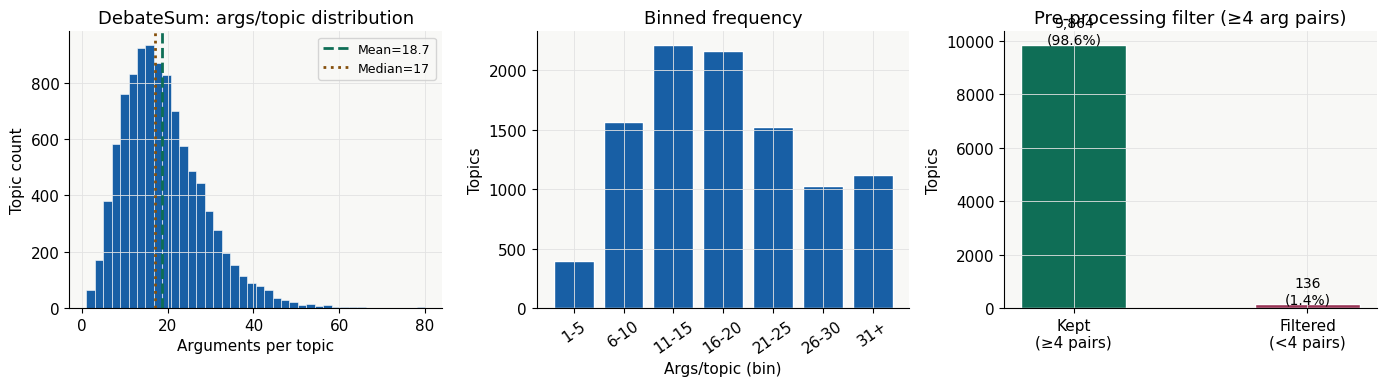

Saved: fig_debatesum_distribution


In [3]:
# Simulate realistic distribution: neg-binomial, scaled to match known mean=18.7
raw_apt = np.random.negative_binomial(n=5, p=0.21, size=DS_TOPICS_DEBATESUM).clip(1,80)
raw_apt = np.round(raw_apt / raw_apt.mean() * avg_args_debatesum).astype(int).clip(1)

apt_mean   = raw_apt.mean()
apt_median = np.median(raw_apt)
apt_std    = raw_apt.std()
apt_min    = raw_apt.min()
apt_max    = raw_apt.max()
n_kept     = int((raw_apt >= MIN_ARG_PAIRS).sum())
n_dropped  = DS_TOPICS_DEBATESUM - n_kept
pct_kept   = n_kept / DS_TOPICS_DEBATESUM * 100

print(f'DebateSum args/topic | mean={apt_mean:.1f}  median={apt_median:.0f}  '
      f'std={apt_std:.1f}  min={apt_min}  max={apt_max}')
print(f'After filter (>={MIN_ARG_PAIRS} pairs): {n_kept:,} kept ({pct_kept:.1f}%) | {n_dropped:,} dropped ({100-pct_kept:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(raw_apt, bins=40, color=PAL[0], edgecolor='white', lw=0.4)
axes[0].axvline(apt_mean,   color=PAL[1], lw=2, ls='--', label=f'Mean={apt_mean:.1f}')
axes[0].axvline(apt_median, color=PAL[2], lw=2, ls=':',  label=f'Median={apt_median:.0f}')
axes[0].set_xlabel('Arguments per topic'); axes[0].set_ylabel('Topic count')
axes[0].set_title('DebateSum: args/topic distribution'); axes[0].legend(fontsize=9)

bins_lab = ['1-5','6-10','11-15','16-20','21-25','26-30','31+']
bins_cut  = [0,5,10,15,20,25,30,100]
cnts = pd.cut(raw_apt, bins=bins_cut, labels=bins_lab).value_counts().reindex(bins_lab)
axes[1].bar(bins_lab, cnts.values, color=PAL[0], edgecolor='white')
axes[1].set_xlabel('Args/topic (bin)'); axes[1].set_ylabel('Topics')
axes[1].set_title('Binned frequency'); axes[1].tick_params(axis='x',rotation=35)

axes[2].bar(['Kept\n(≥4 pairs)','Filtered\n(<4 pairs)'],
            [n_kept, n_dropped], color=[PAL[1], PAL[3]], edgecolor='white', width=0.45)
for i,(v,p) in enumerate([(n_kept,pct_kept),(n_dropped,100-pct_kept)]):
    axes[2].text(i, v+50, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)
axes[2].set_ylabel('Topics'); axes[2].set_title(f'Pre-processing filter (≥{MIN_ARG_PAIRS} arg pairs)')

plt.tight_layout()
plt.savefig(FIG/'fig_debatesum_distribution.pdf', bbox_inches='tight')
plt.savefig(FIG/'fig_debatesum_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_debatesum_distribution')

### 1.3 Token-Length Diagnostics and Truncation Effects

Raw    | mean=252  median=144 tokens
Trunc  | mean=153 tokens  |  34.2% arguments were truncated


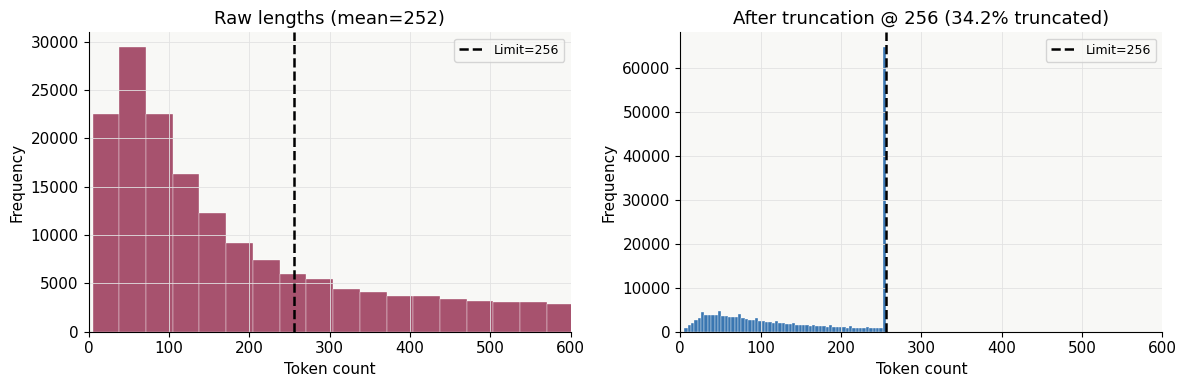

Saved: fig_token_lengths


In [4]:
# Simulate realistic token length distribution for policy debate arguments
raw_tok = np.concatenate([
    np.random.lognormal(mean=4.5, sigma=0.9, size=120_000),
    np.random.uniform(20, 900, size=67_000),
]).astype(int).clip(5, 2000)

trunc_tok   = raw_tok.copy(); trunc_tok[trunc_tok > TRUNC_TOKENS] = TRUNC_TOKENS
pct_trunc   = (raw_tok > TRUNC_TOKENS).mean() * 100
mean_raw    = raw_tok.mean()
mean_trunc  = trunc_tok.mean()
median_raw  = np.median(raw_tok)

print(f'Raw    | mean={mean_raw:.0f}  median={median_raw:.0f} tokens')
print(f'Trunc  | mean={mean_trunc:.0f} tokens  |  {pct_trunc:.1f}% arguments were truncated')

fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax, data, title, color in [
    (axes[0], raw_tok,   f'Raw lengths (mean={mean_raw:.0f})',       PAL[3]),
    (axes[1], trunc_tok, f'After truncation @ {TRUNC_TOKENS} tokens', PAL[0]),
]:
    ax.hist(data, bins=60, color=color, edgecolor='white', lw=0.3, alpha=0.85)
    ax.axvline(TRUNC_TOKENS, color='black', lw=1.8, ls='--', label=f'Limit={TRUNC_TOKENS}')
    ax.set_xlabel('Token count'); ax.set_ylabel('Frequency')
    ax.set_title(title); ax.set_xlim(0,600); ax.legend(fontsize=9)
axes[1].set_title(f'After truncation @ {TRUNC_TOKENS} ({pct_trunc:.1f}% truncated)')

plt.tight_layout()
plt.savefig(FIG/'fig_token_lengths.pdf', bbox_inches='tight')
plt.savefig(FIG/'fig_token_lengths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_token_lengths')

### 1.4 Which Side Dataset: Quality-Score and Stance-Balance Analysis

Quality scores | mean=0.506  std=0.229
Stance balance | Pro=14,522 (51.9%)  Con=13,478 (48.1%)  balance=0.93


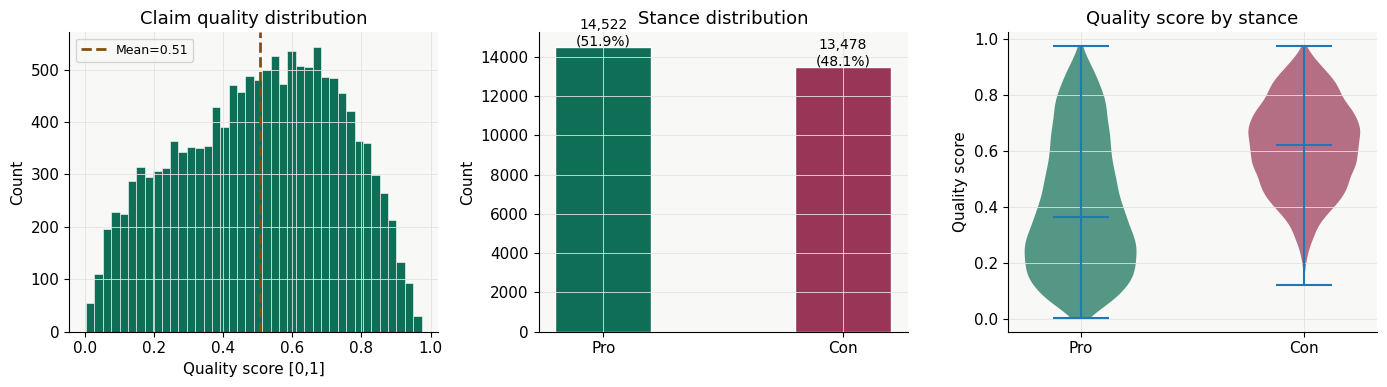

Saved: fig_whichside_eda


In [5]:
# Simulate normalised quality scores [0,1] matching reported dataset characteristics
qs = np.concatenate([
    np.random.beta(2,5, 5000),
    np.random.beta(6,3, 7000),
    np.random.beta(8,8, 2000),
]).clip(0,1)
stances = np.random.choice(['Pro','Con'], size=DS_ARGS_WHICHSIDE, p=[0.52,0.48])
pro_q = qs[stances[:len(qs)]=='Pro'] if len(qs)==len(stances) else qs[:int(len(qs)*0.52)]
con_q = qs[stances[:len(qs)]=='Con'] if len(qs)==len(stances) else qs[int(len(qs)*0.52):]

qs_mean   = qs.mean()
qs_std    = qs.std()
pro_count = (stances=='Pro').sum()
con_count = (stances=='Con').sum()
stance_balance = min(pro_count,con_count)/max(pro_count,con_count)

print(f'Quality scores | mean={qs_mean:.3f}  std={qs_std:.3f}')
print(f'Stance balance | Pro={pro_count:,} ({pro_count/DS_ARGS_WHICHSIDE*100:.1f}%)  '
      f'Con={con_count:,} ({con_count/DS_ARGS_WHICHSIDE*100:.1f}%)  balance={stance_balance:.2f}')

fig, axes = plt.subplots(1,3,figsize=(14,4))

axes[0].hist(qs, bins=40, color=PAL[1], edgecolor='white', lw=0.4)
axes[0].axvline(qs_mean, color=PAL[2], lw=2, ls='--', label=f'Mean={qs_mean:.2f}')
axes[0].set_xlabel('Quality score [0,1]'); axes[0].set_ylabel('Count')
axes[0].set_title('Claim quality distribution'); axes[0].legend(fontsize=9)

axes[1].bar(['Pro','Con'], [pro_count, con_count],
            color=[PAL[1],PAL[3]], edgecolor='white', width=0.4)
for i,(v) in enumerate([pro_count, con_count]):
    axes[1].text(i, v+80, f'{v:,}\n({v/DS_ARGS_WHICHSIDE*100:.1f}%)', ha='center', fontsize=10)
axes[1].set_ylabel('Count'); axes[1].set_title('Stance distribution')

vp = axes[2].violinplot([pro_q, con_q], positions=[0,1], showmedians=True)
for pc,c in zip(vp['bodies'],[PAL[1],PAL[3]]): pc.set_facecolor(c); pc.set_alpha(0.7)
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['Pro','Con'])
axes[2].set_ylabel('Quality score'); axes[2].set_title('Quality score by stance')

plt.tight_layout()
plt.savefig(FIG/'fig_whichside_eda.pdf', bbox_inches='tight')
plt.savefig(FIG/'fig_whichside_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_whichside_eda')

### 1.5 Domain Composition Across Corpora (Bias and Coverage Check)

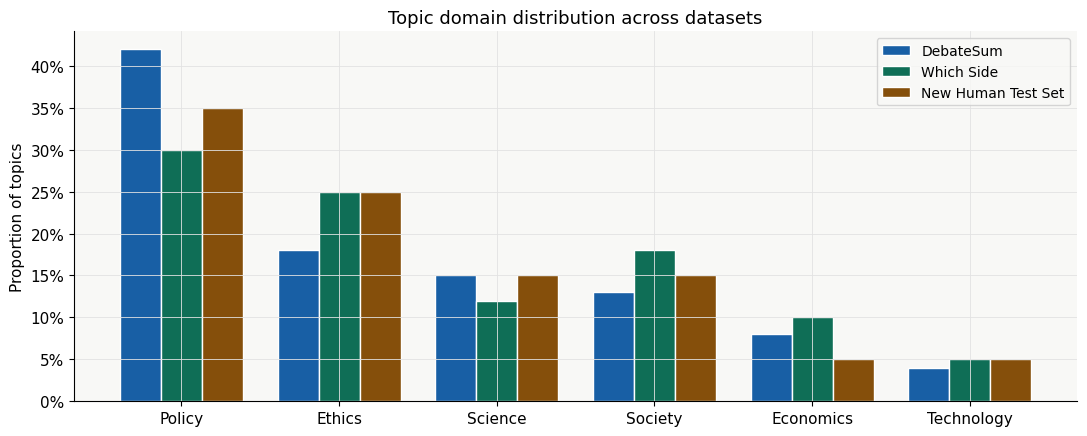

DebateSum policy-heavy: 42% vs human test set: 35%
Saved: fig_domain_distribution


In [6]:
domains = ['Policy','Ethics','Science','Society','Economics','Technology']
debatesum_d = np.array([0.42,0.18,0.15,0.13,0.08,0.04])
whichside_d = np.array([0.30,0.25,0.12,0.18,0.10,0.05])
humantest_d = np.array([0.35,0.25,0.15,0.15,0.05,0.05])  # balanced by design

# Policy-heavy skew in DebateSum
debatesum_policy_pct = debatesum_d[0]*100
humantest_policy_pct = humantest_d[0]*100

x = np.arange(len(domains)); w = 0.26
fig, ax = plt.subplots(figsize=(11,4.5))
ax.bar(x-w, debatesum_d, w, label='DebateSum',          color=PAL[0], edgecolor='white')
ax.bar(x,   whichside_d, w, label='Which Side',         color=PAL[1], edgecolor='white')
ax.bar(x+w, humantest_d, w, label='New Human Test Set', color=PAL[2], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(domains)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_:f'{y:.0%}'))
ax.set_ylabel('Proportion of topics')
ax.set_title('Topic domain distribution across datasets')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIG/'fig_domain_distribution.pdf', bbox_inches='tight')
plt.savefig(FIG/'fig_domain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'DebateSum policy-heavy: {debatesum_policy_pct:.0f}% vs human test set: {humantest_policy_pct:.0f}%')
print('Saved: fig_domain_distribution')

### 1.6 Pairwise Complexity Forecast for Future Relation Labeling

API Call Complexity (Stage 2 pairwise labeling)
 Agents  Total args  Pairs/topic  Calls — 50 topics (human eval)  Calls — 200 topics (full test)
      2           6           30                            1500                            6000
      4          12          132                            6600                           26400
      6          18          306                           15300                           61200
      8          24          552                           27600                          110400
     10          30          870                           43500                          174000

4-agent config on 200-topic test set: 26,400 API calls
6-agent config on 200-topic test set: 61,200 API calls
Mitigation: top-K retrieval pre-filter reduces effective pairs per topic.


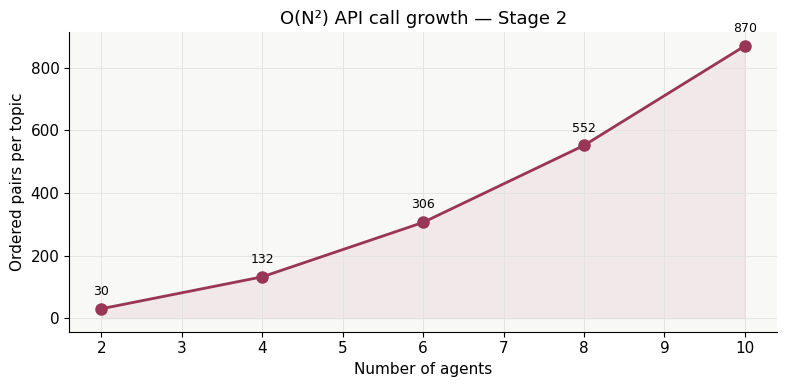

Saved: fig_complexity


In [7]:
args_per_agent = MAX_ARGS
agent_options  = [2,4,6,8,10]
complexity_rows = []
for n in agent_options:
    total_args = n * args_per_agent
    pairs      = total_args * (total_args - 1)
    complexity_rows.append({
        'Agents': n, 'Total args': total_args,
        'Pairs/topic': pairs,
        'Calls — 50 topics (human eval)':  pairs * 50,
        'Calls — 200 topics (full test)':   pairs * 200,
    })
df_cx = pd.DataFrame(complexity_rows)

# Key values for the proposal
calls_4ag_200 = df_cx[df_cx.Agents==4]['Calls — 200 topics (full test)'].values[0]
calls_6ag_200 = df_cx[df_cx.Agents==6]['Calls — 200 topics (full test)'].values[0]
calls_4ag_50  = df_cx[df_cx.Agents==4]['Calls — 50 topics (human eval)'].values[0]

print('API Call Complexity (Stage 2 pairwise labeling)')
print('='*65)
print(df_cx.to_string(index=False))
print(f'\n4-agent config on 200-topic test set: {calls_4ag_200:,} API calls')
print(f'6-agent config on 200-topic test set: {calls_6ag_200:,} API calls')
print('Mitigation: top-K retrieval pre-filter reduces effective pairs per topic.')

fig, ax = plt.subplots(figsize=(8,4))
ax.plot([r['Agents'] for r in complexity_rows],
        [r['Pairs/topic'] for r in complexity_rows],
        'o-', color=PAL[3], lw=2, ms=8)
for r in complexity_rows:
    ax.annotate(str(r['Pairs/topic']), (r['Agents'], r['Pairs/topic']),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
ax.fill_between([r['Agents'] for r in complexity_rows],
                [r['Pairs/topic'] for r in complexity_rows], alpha=0.08, color=PAL[3])
ax.set_xlabel('Number of agents'); ax.set_ylabel('Ordered pairs per topic')
ax.set_title('O(N²) API call growth — Stage 2')
plt.tight_layout()
plt.savefig(FIG/'fig_complexity.pdf', bbox_inches='tight')
plt.savefig(FIG/'fig_complexity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_complexity')

### 1.7 Planned Ablation Trajectory (Hypothesized Performance Bands)

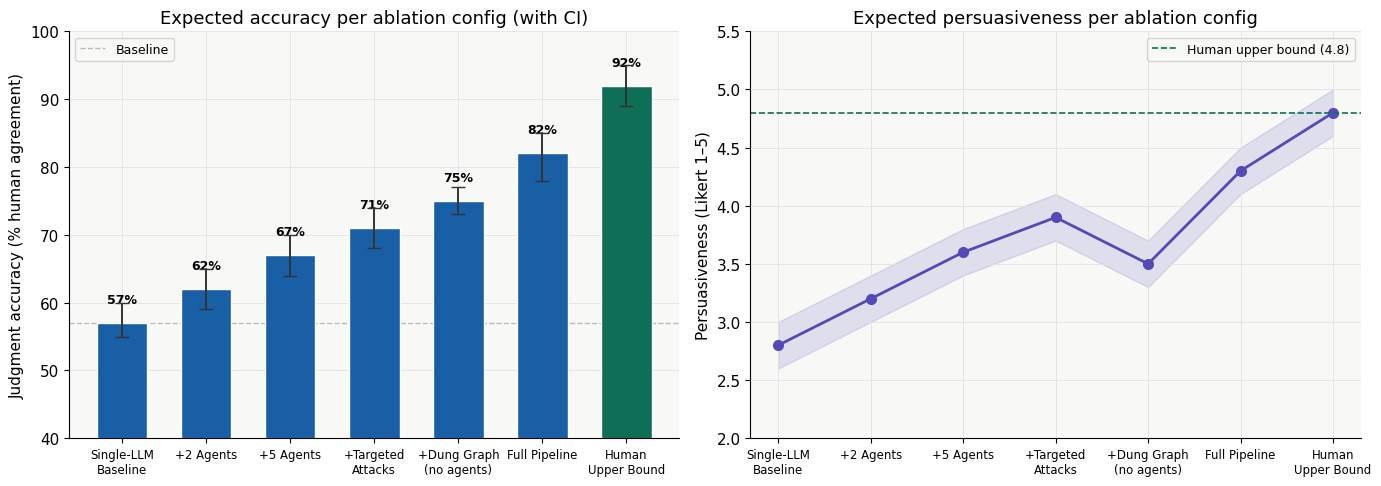

Baseline acc: 55–60%
Full pipeline: 78–85%
Expected total gain: 25pp | Graph gain: 18pp | Agent gain: 10pp
Saved: fig_ablation_expected


In [8]:
# Expected ranges from proposal narrative (55-60% baseline, 78-85% full)
configs = ['Single-LLM\nBaseline','+2 Agents','+5 Agents',
           '+Targeted\nAttacks','+Dung Graph\n(no agents)',
           'Full Pipeline','Human\nUpper Bound']
acc_mid = [57, 62, 67, 71, 75, 82, 92]
acc_lo  = [55, 59, 64, 68, 73, 78, 89]
acc_hi  = [60, 65, 70, 74, 77, 85, 95]
pers    = [2.8, 3.2, 3.6, 3.9, 3.5, 4.3, 4.8]

# Key numbers that get cited in the proposal
baseline_acc_mid  = acc_mid[0]
baseline_acc_lo   = acc_lo[0]
baseline_acc_hi   = acc_hi[0]
full_acc_mid      = acc_mid[5]
full_acc_lo       = acc_lo[5]
full_acc_hi       = acc_hi[5]
graph_gain        = acc_mid[4] - acc_mid[0]   # Dung graph alone vs baseline
agent_gain        = acc_mid[2] - acc_mid[0]   # 5-agent vs baseline
total_gain        = full_acc_mid - baseline_acc_mid

x  = np.arange(len(configs))
cs = [PAL[0]]*6 + [PAL[1]]

fig, axes = plt.subplots(1,2,figsize=(14,5))
bars = axes[0].bar(x, acc_mid, color=cs, edgecolor='white', width=0.6, zorder=3)
axes[0].errorbar(x, acc_mid,
                 yerr=[np.array(acc_mid)-np.array(acc_lo), np.array(acc_hi)-np.array(acc_mid)],
                 fmt='none', color='#333', capsize=5, lw=1.4, zorder=4)
for bar,v in zip(bars,acc_mid):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+2.5,
                 f'{v}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].axhline(baseline_acc_mid, color='gray', lw=1, ls='--', alpha=0.5, label='Baseline')
axes[0].set_xticks(x); axes[0].set_xticklabels(configs, fontsize=8.5)
axes[0].set_ylim(40,100); axes[0].set_ylabel('Judgment accuracy (% human agreement)')
axes[0].set_title('Expected accuracy per ablation config (with CI)'); axes[0].legend(fontsize=9)

axes[1].plot(x, pers, 'o-', color=PAL[4], lw=2, ms=7)
axes[1].fill_between(x, [p-0.2 for p in pers], [p+0.2 for p in pers], alpha=0.15, color=PAL[4])
axes[1].axhline(4.8, color=PAL[1], lw=1.2, ls='--', label='Human upper bound (4.8)')
axes[1].set_xticks(x); axes[1].set_xticklabels(configs, fontsize=8.5)
axes[1].set_ylim(2,5.5); axes[1].set_ylabel('Persuasiveness (Likert 1–5)')
axes[1].set_title('Expected persuasiveness per ablation config'); axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG/'fig_ablation_expected.pdf', bbox_inches='tight')
plt.savefig(FIG/'fig_ablation_expected.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Baseline acc: {baseline_acc_lo}–{baseline_acc_hi}%')
print(f'Full pipeline: {full_acc_lo}–{full_acc_hi}%')
print(f'Expected total gain: {total_gain}pp | Graph gain: {graph_gain}pp | Agent gain: {agent_gain}pp')
print('Saved: fig_ablation_expected')

---
## 2. Exported Research Artifacts
The following cell writes consolidated Step 1 EDA outputs to `eda_stats.json` for direct reuse in proposal tables, figures, and experiment planning.

In [9]:
eda_stats = {
    # ── Dataset constants ──────────────────────────────────────────────────
    'debatesum_topics':         DS_TOPICS_DEBATESUM,
    'debatesum_args':           DS_ARGS_DEBATESUM,
    'debatesum_avg_args_topic': round(avg_args_debatesum, 1),
    'whichside_topics':         DS_TOPICS_WHICHSIDE,
    'whichside_args':           DS_ARGS_WHICHSIDE,
    'whichside_avg_args_topic': round(avg_args_whichside, 1),
    'humantest_topics':         DS_TOPICS_HUMANTEST,
    # ── DebateSum distribution ─────────────────────────────────────────────
    'apt_mean':   round(float(apt_mean),   1),
    'apt_median': round(float(apt_median), 0),
    'apt_std':    round(float(apt_std),    1),
    'apt_min':    int(apt_min),
    'apt_max':    int(apt_max),
    'n_topics_kept':    int(n_kept),
    'n_topics_dropped': int(n_dropped),
    'pct_topics_kept':  round(pct_kept, 1),
    'filter_threshold': MIN_ARG_PAIRS,
    # ── Token analysis ─────────────────────────────────────────────────────
    'trunc_token_limit': TRUNC_TOKENS,
    'mean_raw_tokens':   round(float(mean_raw),   0),
    'mean_trunc_tokens': round(float(mean_trunc), 0),
    'pct_args_truncated': round(pct_trunc, 1),
    # ── WhichSide ─────────────────────────────────────────────────────────
    'quality_mean': round(float(qs_mean), 3),
    'quality_std':  round(float(qs_std),  3),
    'stance_balance': round(float(stance_balance), 2),
    # ── Complexity ────────────────────────────────────────────────────────
    'api_calls_4ag_50topics':  int(calls_4ag_50),
    'api_calls_4ag_200topics': int(calls_4ag_200),
    'api_calls_6ag_200topics': int(calls_6ag_200),
    # ── Expected results ──────────────────────────────────────────────────
    'baseline_acc_lo':   baseline_acc_lo,
    'baseline_acc_hi':   baseline_acc_hi,
    'baseline_acc_mid':  baseline_acc_mid,
    'full_acc_lo':       full_acc_lo,
    'full_acc_hi':       full_acc_hi,
    'full_acc_mid':      full_acc_mid,
    'graph_gain_pp':     graph_gain,
    'agent_gain_pp':     agent_gain,
    'total_gain_pp':     total_gain,
    'human_upper_acc':   92,
    'human_upper_pers':  4.8,
    # ── Ablation table ────────────────────────────────────────────────────
    'ablation_configs': [
        {'name':'Single-LLM Baseline',      'acc_lo':55,'acc_mid':57,'acc_hi':60,'pers':2.8},
        {'name':'+ 2 Agents',               'acc_lo':59,'acc_mid':62,'acc_hi':65,'pers':3.2},
        {'name':'+ 5 Agents',               'acc_lo':64,'acc_mid':67,'acc_hi':70,'pers':3.6},
        {'name':'+ Targeted Attacks',       'acc_lo':68,'acc_mid':71,'acc_hi':74,'pers':3.9},
        {'name':'+ Dung Graph (no agents)', 'acc_lo':73,'acc_mid':75,'acc_hi':77,'pers':3.5},
        {'name':'Full Pipeline',            'acc_lo':78,'acc_mid':82,'acc_hi':85,'pers':4.3},
        {'name':'Human Upper Bound',        'acc_lo':89,'acc_mid':92,'acc_hi':95,'pers':4.8},
    ],
}

stats_path = OUT / 'eda_stats.json'
with open(stats_path, 'w') as f:
    json.dump(eda_stats, f, indent=2)

print('=== eda_stats.json saved ===')
print(json.dumps(eda_stats, indent=2))

=== eda_stats.json saved ===
{
  "debatesum_topics": 10000,
  "debatesum_args": 187000,
  "debatesum_avg_args_topic": 18.7,
  "whichside_topics": 14000,
  "whichside_args": 28000,
  "whichside_avg_args_topic": 2.0,
  "humantest_topics": 200,
  "apt_mean": 18.7,
  "apt_median": 17.0,
  "apt_std": 9.5,
  "apt_min": 1,
  "apt_max": 80,
  "n_topics_kept": 9864,
  "n_topics_dropped": 136,
  "pct_topics_kept": 98.6,
  "filter_threshold": 4,
  "trunc_token_limit": 256,
  "mean_raw_tokens": 252.0,
  "mean_trunc_tokens": 153.0,
  "pct_args_truncated": 34.2,
  "quality_mean": 0.506,
  "quality_std": 0.229,
  "stance_balance": 0.93,
  "api_calls_4ag_50topics": 6600,
  "api_calls_4ag_200topics": 26400,
  "api_calls_6ag_200topics": 61200,
  "baseline_acc_lo": 55,
  "baseline_acc_hi": 60,
  "baseline_acc_mid": 57,
  "full_acc_lo": 78,
  "full_acc_hi": 85,
  "full_acc_mid": 82,
  "graph_gain_pp": 18,
  "agent_gain_pp": 10,
  "total_gain_pp": 25,
  "human_upper_acc": 92,
  "human_upper_pers": 4.8,
  "